In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## Exploratory Data Analysis

In [7]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Shape: (200, 4)

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive statistics:



,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


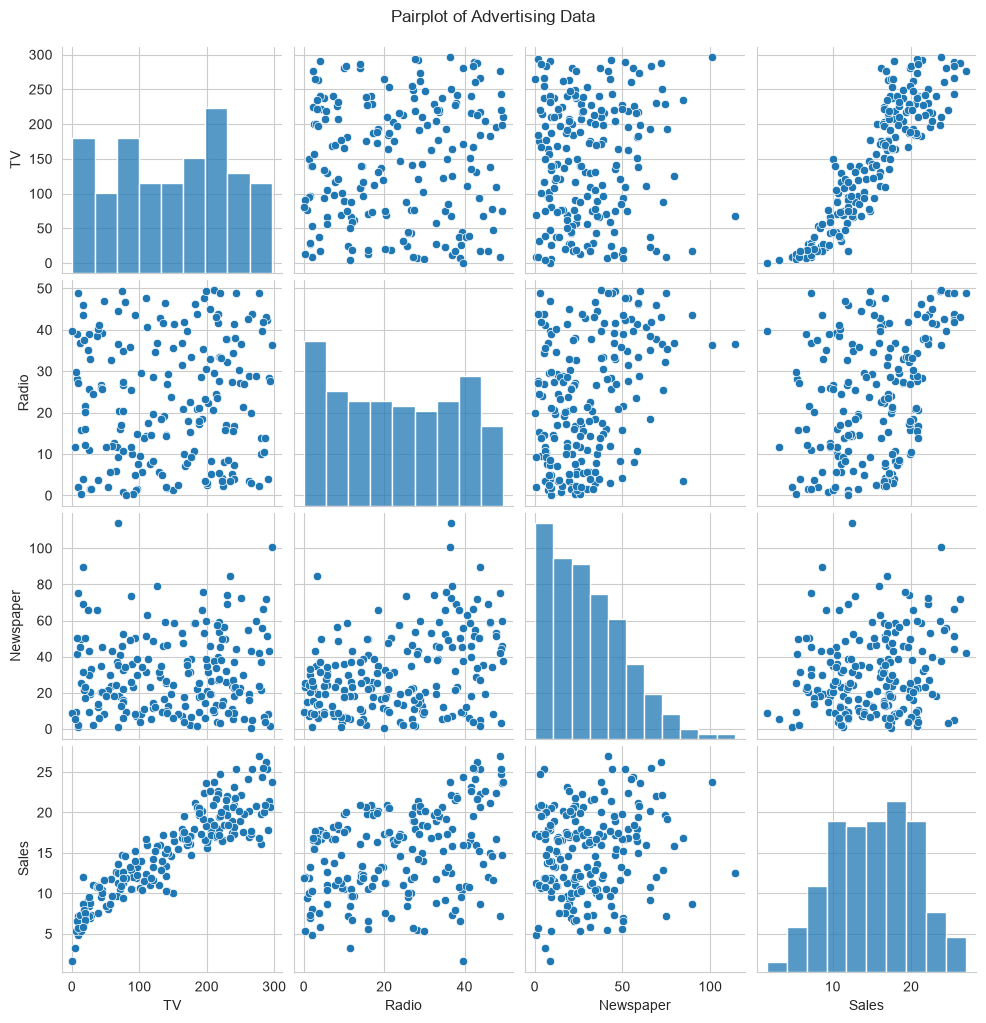

In [8]:
sns.pairplot(df)
plt.suptitle("Pairplot of Advertising Data", y=1.02)
plt.show()

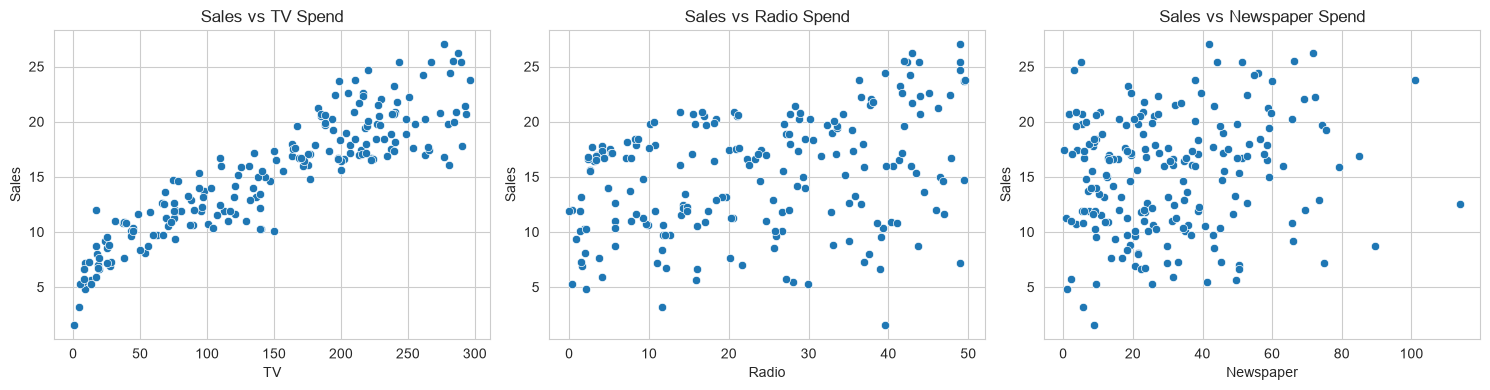

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x='TV', y='Sales', data=df, ax=axes[0])
axes[0].set_title('Sales vs TV Spend')

sns.scatterplot(x='Radio', y='Sales', data=df, ax=axes[1])
axes[1].set_title('Sales vs Radio Spend')

sns.scatterplot(x='Newspaper', y='Sales', data=df, ax=axes[2])
axes[2].set_title('Sales vs Newspaper Spend')

plt.tight_layout()
plt.show()

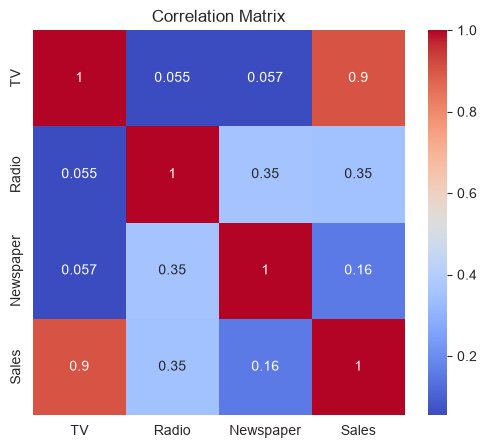

In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Train/Test Split & Model Training

In [11]:
X = df.drop('Sales', axis=1)
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (160, 3) Test size: (40, 3)


In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


In [13]:
models = {"Linear Regression": lr_model, "Random Forest": rf_model}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R² Score: {r2:.3f}")


Model: Linear Regression
MAE: 1.275
RMSE: 1.705
R² Score: 0.906

Model: Random Forest
MAE: 0.918
RMSE: 1.199
R² Score: 0.953


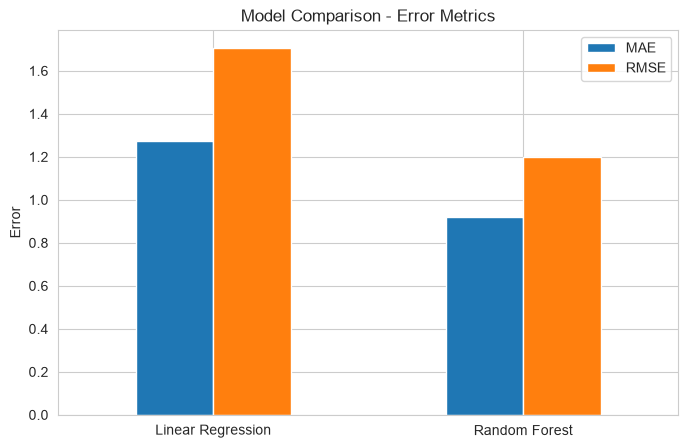

                        MAE      RMSE        R2
Linear Regression  1.274826  1.705215  0.905901
Random Forest      0.918000  1.198930  0.953483


In [14]:
results_df = pd.DataFrame(results).T
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5))
plt.title("Model Comparison - Error Metrics")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

print(results_df)

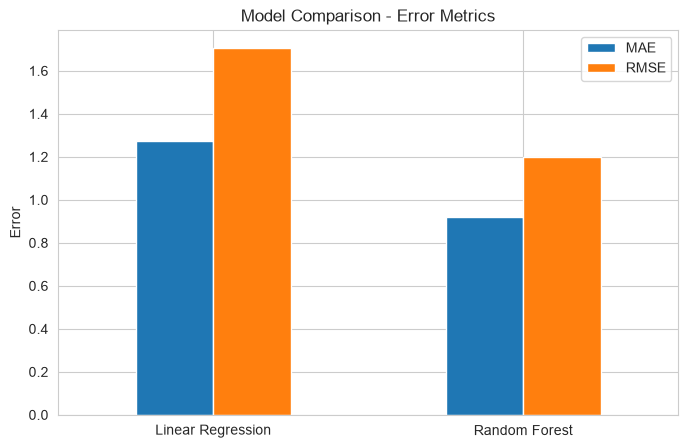

                        MAE      RMSE        R2
Linear Regression  1.274826  1.705215  0.905901
Random Forest      0.918000  1.198930  0.953483


In [15]:
results_df = pd.DataFrame(results).T
results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 5))
plt.title("Model Comparison - Error Metrics")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

print(results_df)

Best performing model: Random Forest (R² = 0.953)


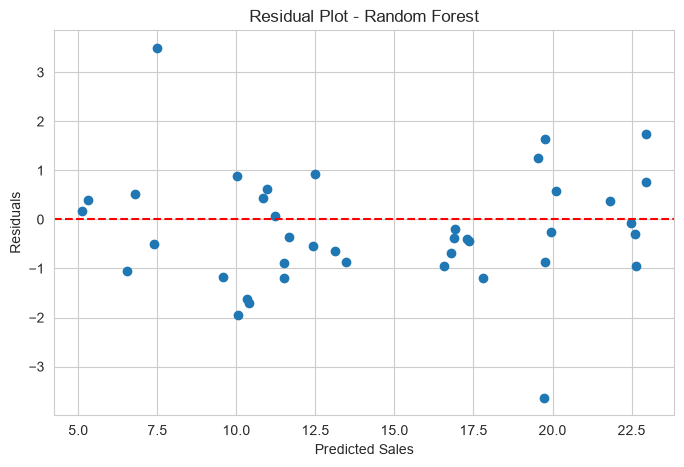

In [16]:
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name} (R² = {results_df.loc[best_model_name, 'R2']:.3f})")

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")
plt.show()

     Feature  Importance
0         TV    0.845355
1      Radio    0.136642
2  Newspaper    0.018003


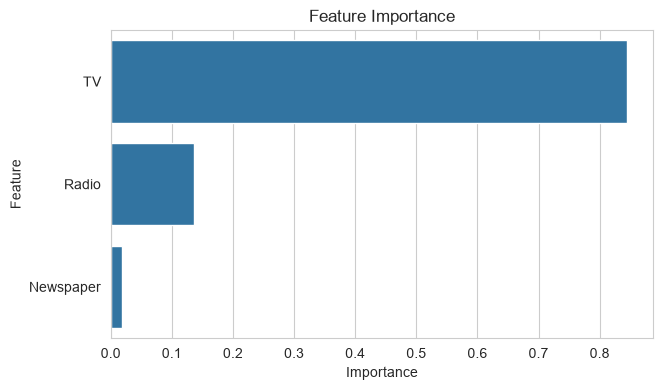

In [17]:
if best_model_name == "Linear Regression":
    coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": best_model.coef_})
    print(coef_df.sort_values("Coefficient", ascending=False))
else:
    importance_df = pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_})
    print(importance_df.sort_values("Importance", ascending=False))

    plt.figure(figsize=(7, 4))
    sns.barplot(x="Importance", y="Feature", data=importance_df.sort_values("Importance", ascending=False))
    plt.title("Feature Importance")
    plt.show()

## Conclusion

Random Forest performed best with the highest R² score and lowest error metrics.
Looking at the feature importance, TV advertising spend has by far the strongest 
impact on Sales (84.5% importance), followed by Radio (13.7%), while Newspaper 
spend shows almost no relationship with Sales (1.8%). This matches the correlation 
heatmap, where TV had the highest correlation with Sales.